In [1]:
import pandas as pd
import numpy as np

import joblib

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

In [2]:
train = pd.read_csv("../data/train_processed.csv")

test = pd.read_csv("../data/test_processed.csv")

In [3]:
X_train = train.drop("depression_label", axis=1)
y_train = train["depression_label"]

X_test = test.drop("depression_label", axis=1)
y_test = test["depression_label"]

In [4]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "SVM":
        SVC(probability=True),

    "KNN":
        KNeighborsClassifier(),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
}

In [5]:
results = []

trained_models = {}

for name, model in models.items():

    print("=" * 60)

    print(name)

    model.fit(X_train, y_train)

    trained_models[name] = model

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    pre = precision_score(y_test, pred)

    rec = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    auc = roc_auc_score(
        y_test,
        model.predict_proba(X_test)[:,1]
    )

    results.append([
        name,
        acc,
        pre,
        rec,
        f1,
        auc
    ])

Logistic Regression
Decision Tree
Random Forest


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Extra Trees
Gradient Boosting
SVM
KNN


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


XGBoost


In [6]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,1.0000,1.0,1.0,1.000000,1.000000
4,Gradient Boosting,1.0000,1.0,1.0,1.000000,1.000000
7,XGBoost,1.0000,1.0,1.0,1.000000,1.000000
0,Logistic Regression,0.9875,1.0,0.5,0.666667,0.994302
2,Random Forest,0.9750,0.0,0.0,0.000000,1.000000
3,Extra Trees,0.9750,0.0,0.0,0.000000,0.996439
5,SVM,0.9750,0.0,0.0,0.000000,0.991453
6,KNN,0.9750,0.0,0.0,0.000000,0.723647


In [7]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print(best_model_name)

Decision Tree


In [8]:
prediction = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        prediction
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00         6

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print(scores)

print("Mean Accuracy :", scores.mean())

[1.         1.         0.97916667 1.         0.99479167]
Mean Accuracy : 0.9947916666666666


In [10]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,20,None],

    "min_samples_split":[2,5,10]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [11]:
print(grid.best_params_)

print(grid.best_score_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
0.975


In [12]:
best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       234
           1       0.00      0.00      0.00         6

    accuracy                           0.97       240
   macro avg       0.49      0.50      0.49       240
weighted avg       0.95      0.97      0.96       240



c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [13]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
2,num__sleep_hours,0.202800
1,num__daily_social_media_hours,0.168764
6,num__stress_level,0.144021
7,num__anxiety_level,0.115871
4,num__academic_performance,0.068817
3,num__screen_time_before_sleep,0.063565
5,num__physical_activity,0.059737
8,num__addiction_level,0.049179
0,num__age,0.038168
10,cat__gender_male,0.019847


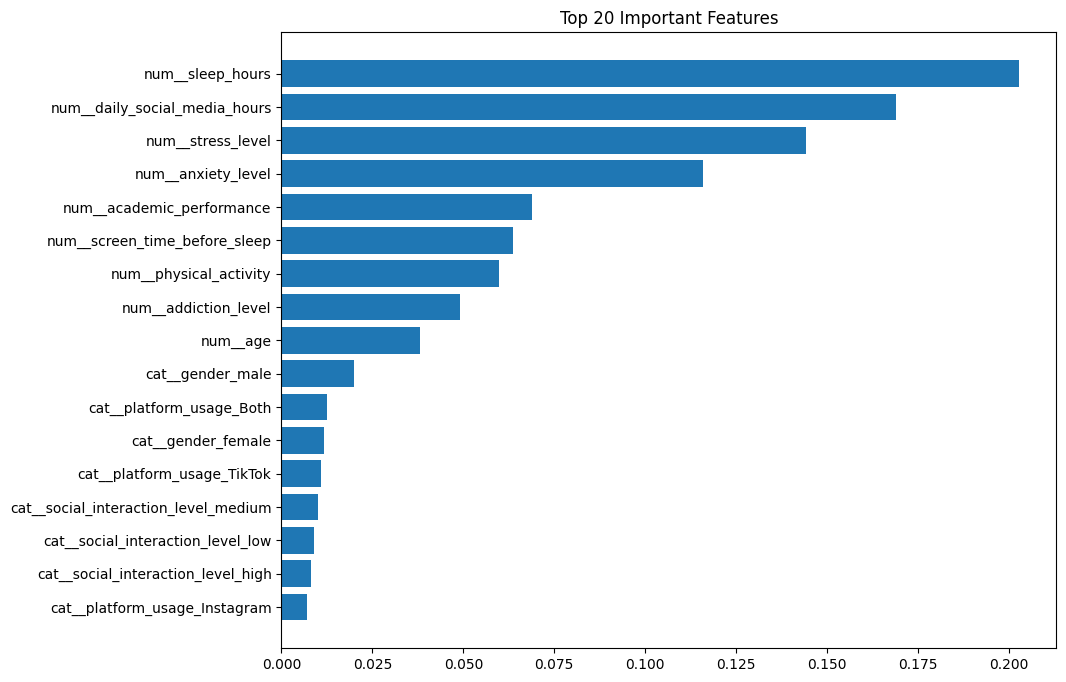

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:20],

    importance["Importance"][:20]

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [15]:
joblib.dump(best_rf,"../models/best_model.pkl")

print("Best model saved!")

Best model saved!
